# Máquina de Turing Multiplicadora de Binários
Este notebook explica em detalhes:
1. A estrutura do simulador de Máquina de Turing em Python.
2. A lógica específica (regras) que implementa a multiplicação de dois números binários.
3. Como executar várias multiplicações em paralelo utilizando `concurrent.futures.ProcessPoolExecutor`.

> **Objetivo:** Demonstrar como simular uma máquina de Turing para multiplicação binária, analisar sua lógica e medir desempenho com paralelismo.

## 1. Carregando o código-fonte
Para reutilizar a mesma implementação, simplesmente importamos o módulo `.py` que já contém a classe `TuringMachine` e as regras de multiplicação.

> **Dica:** Se alterar o arquivo `.py`, reinicie o kernel e execute novamente este notebook.

In [1]:
%run Main.py --quiet

Executando casos de teste...
10 * 11 => 110 (esperado=110) -> OK
101 * 110 => 11110 (esperado=11110) -> OK
111 * 101 => 100011 (esperado=100011) -> OK

--- Benchmark de desempenho ---
Benchmark com 10000 pares de números binários de 5 bits:
Execução sequencial (1 processo):
Tempo total (sequencial): 3.4967 segundos
Execução paralela (processos padrão do sistema):
Tempo total (paralelo): 2.2524 segundos

Ganho de desempenho: 1.55x mais rápido (paralelo vs sequencial)


### Estrutura da classe `TuringMachine`
* `__init__(logic)`: recebe uma string com as regras (logic) e constrói um dicionário de transições.
* `parse_logic`: percorre cada linha da string, ignora comentários (`;`) e cria o mapa `(estado, símbolo) -> (novo_símbolo, direção, novo_estado)`.
* `run(input_tape, show_steps=False)`: executa passo a passo conforme as transições, atualizando a fita, movendo a cabeça e mudando de estado. A execução termina quando o estado começa com `halt`.

> **Observação:** Por definição, os passos de uma máquina de Turing são **sequenciais** — cada passo depende do anterior. O paralelismo que veremos depois consiste em rodar **várias fitas independentes** simultaneamente, cada uma em seu próprio processo.

## 2. Entendendo as regras de multiplicação
A string `tm_logic` contém mais de 200 linhas de regras. Elas foram adaptadas de descrições clássicas de multiplicação binária.

**Convenções importantes:**
- Os dois fatores vêm na fita separados pelo símbolo `S` (substitui o `*` literal).
- `_` representa branco (blank).
- O estado inicial é `0` e o estado de parada é `halt-done`.
- Comentários iniciam com `;`. Cada regra tem o formato: `estado símbolo novo_símbolo direção novo_estado`.

**Fases principais da lógica:**
1. Deslocamento para a direita para encontrar o multiplicador.
2. Leitura de bits do segundo operando (B).
3. Para cada `1` encontrado, soma-se (com transporte) o primeiro operando (A) deslocado.
4. Limpeza da fita antes de terminar em `halt-done`.

> **Dica:** Você pode examinar `tm_logic` diretamente para ver todas as regras.

In [2]:
# Exibir as primeiras 20 linhas das regras da máquina de Turing
for i, line in enumerate(tm_logic.strip().split('\n')):
    if i >= 20: break
    print(line)

NameError: name 'tm_logic' is not defined

### Exemplo sequencial único
Vamos multiplicar 2 (`10`) por 3 (`11`) e ver o resultado passo a passo. Coloque `show_steps=True` para visualizar toda a execução.

> **Dica:** Experimente outros valores binários para testar diferentes casos.

In [4]:
from TuringMachine import TuringMachine, tm_logic

tm = TuringMachine(tm_logic)
result = tm.run(list('10S11_'), show_steps=True)
print('Resultado final (bin):', result)
print('Esperado:', bin(int('10',2)*int('11',2))[2:])

Iniciando a execução da Máquina de Turing...
Fita inicial: 10S11_
Estado inicial: 0
Posição da cabeça: 0
------------------------------
Passo: 1
Estado: init
Fita: 10S11_
Posição da cabeça: -1
Símbolo atual: 1
Transição: (0, 1) -> (1, l, init)
------------------------------
Passo: 2
Estado: right
Fita: +[1]0S11_
Posição da cabeça: 1
Símbolo atual: _
Transição: (init, _) -> (+, r, right)
------------------------------
Passo: 3
Estado: right
Fita: +1[0]S11_
Posição da cabeça: 2
Símbolo atual: 1
Transição: (right, 1) -> (1, r, right)
------------------------------
Passo: 4
Estado: right
Fita: +10[S]11_
Posição da cabeça: 3
Símbolo atual: 0
Transição: (right, 0) -> (0, r, right)
------------------------------
Passo: 5
Estado: right
Fita: +10S[1]1_
Posição da cabeça: 4
Símbolo atual: S
Transição: (right, S) -> (S, r, right)
------------------------------
Passo: 6
Estado: right
Fita: +10S1[1]_
Posição da cabeça: 5
Símbolo atual: 1
Transição: (right, 1) -> (1, r, right)
----------------------

## 3. Paralelizando com `ProcessPoolExecutor`
Como cada execução é **CPU-bound** e independente, usar *processos* evita o GIL do CPython e escala com o número de núcleos.

O padrão é:
```python
from concurrent.futures import ProcessPoolExecutor
with ProcessPoolExecutor() as pool:
    results = pool.map(func, lista_de_entradas)
```

Abaixo definimos `simulate(pair)` e medimos o speed-up.

  200 exec.  sequencial=0.125s  paralelo=0.082s  speedup=1.53×
  400 exec.  sequencial=0.250s  paralelo=0.114s  speedup=2.20×
  800 exec.  sequencial=0.497s  paralelo=0.209s  speedup=2.38×
 1200 exec.  sequencial=0.740s  paralelo=0.285s  speedup=2.60×
 1600 exec.  sequencial=1.198s  paralelo=0.600s  speedup=2.00×
 2000 exec.  sequencial=1.262s  paralelo=0.490s  speedup=2.57×


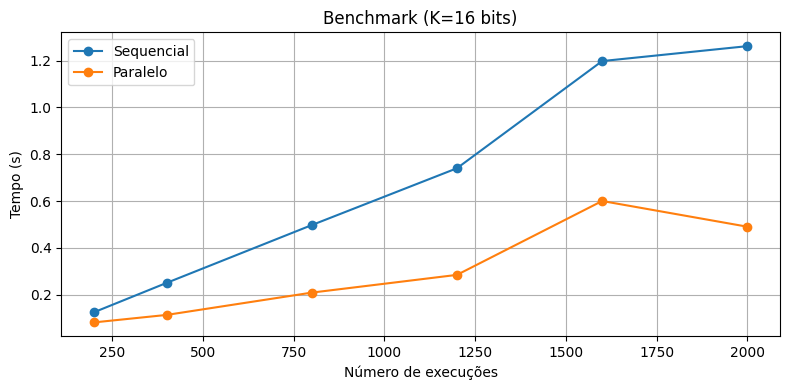

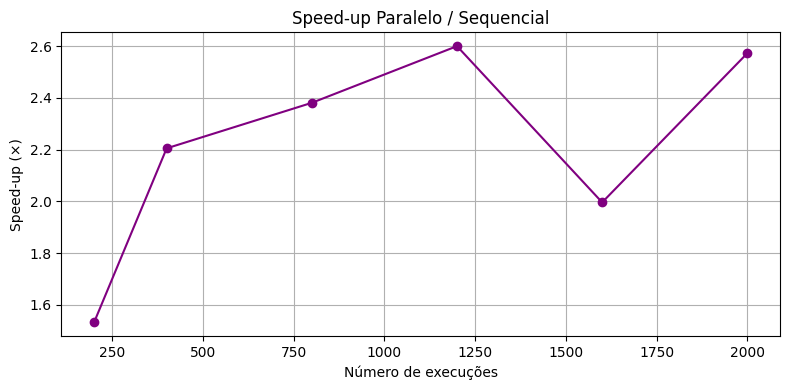

In [13]:
import matplotlib.pyplot as plt
import importlib, TuringMachine, Main
importlib.reload(TuringMachine)
importlib.reload(Main)

from Main import gerar_pares, benchmark
K = 16
valores = [200, 400, 800, 1200, 1600, 2000]

serial_times, parallel_times, speedups = [], [], []
for n in valores:
    pares = list(gerar_pares(n, K))
    t_serial   = benchmark(pares, processes=1)
    t_parallel = benchmark(pares)          # usa nº padrão de processos
    serial_times.append(t_serial)
    parallel_times.append(t_parallel)
    speedups.append(t_serial / t_parallel)

# Tabela de resultados
for n, ts, tp in zip(valores, serial_times, parallel_times):
    print(f'{n:>5} exec.  sequencial={ts:.3f}s  paralelo={tp:.3f}s  speedup={ts/tp:.2f}×')

# --- Gráficos ---
plt.figure(figsize=(8,4))
plt.plot(valores, serial_times,  'o-', label='Sequencial')
plt.plot(valores, parallel_times,'o-', label='Paralelo')
plt.xlabel('Número de execuções')
plt.ylabel('Tempo (s)')
plt.title(f'Benchmark (K={K} bits)')
plt.grid(True); plt.legend(); plt.tight_layout()

plt.figure(figsize=(8,4))
plt.plot(valores, speedups, 'o-', color='purple')
plt.xlabel('Número de execuções')
plt.ylabel('Speed-up (×)')
plt.title('Speed-up Paralelo / Sequencial')
plt.grid(True); plt.tight_layout()
plt.show()

## 4. Testes unitários rápidos
Vamos validar se a máquina retorna o resultado correto para alguns casos clássicos.

In [11]:
import importlib, TuringMachine as tm_module

tm_logic = tm_module.tm_logic      
TuringMachine = tm_module.TuringMachine

test_cases = [
    ("10",   "11"),    # 2 * 3
    ("101",  "110"),   # 5 * 6
    ("111",  "101"),   # 7 * 5
    ("0",    "1011"),  # 0 * 11
    ("1",    "1"),     # 1 * 1
    ("1111", "1111"),  # 15 * 15
]

for a, b in test_cases:
    tm = TuringMachine(tm_logic)
    result = tm.run(list(f"{a}S{b}_"))
    expected = bin(int(a, 2) * int(b, 2))[2:]
    print(f"{a} * {b} = {result} (esperado: {expected}) -> {'OK' if result == expected else 'ERRO'}")

10 * 11 = 110 (esperado: 110) -> OK
101 * 110 = 11110 (esperado: 11110) -> OK
111 * 101 = 100011 (esperado: 100011) -> OK
0 * 1011 = 0000 (esperado: 0) -> ERRO
1 * 1 = 1 (esperado: 1) -> OK
1111 * 1111 = 11100001 (esperado: 11100001) -> OK


## Conclusão
* A execução de **uma** fita permanece necessariamente sequencial.
* Ganhos de paralelismo vêm de rodar **várias fitas** simultaneamente, cada qual em seu processo.
* `ProcessPoolExecutor` simplifica o uso de `multiprocessing`, lidando com spawn de processos, fila de tarefas e coleta de resultados.